### Imports

In [11]:
import torch
import torch.nn as nn
import torch.optim as optim
import pandas as pd
import seaborn as sns
from sklearn.metrics import accuracy_score, classification_report
from scipy import stats
from scipy.stats import f_oneway, chi2_contingency
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.decomposition import PCA
print(f'PyTorch version: {torch.__version__}')
print(f'CUDA available:  {torch.cuda.is_available()}')
print(f'MPS available:  {torch.backends.mps.is_available()}')
print(f'XPU available:  {torch.xpu.is_available()}')

data = pd.read_csv('PartII_dev.csv')




PyTorch version: 2.11.0+xpu
CUDA available:  False
MPS available:  False
XPU available:  True


Number of features: 125
Number of samples: 158
Number of classes: Y
0    126
1     32
Name: count, dtype: int64
=== ANOVA Results ===
Feature  F-Statistic      P-Value  Significant
   X105    32.929074 4.833682e-08         True
   X103    29.630528 1.989584e-07         True
   X115    28.698951 2.982828e-07         True
   X113    28.466345 3.301451e-07         True
    X55    28.036949 3.983325e-07         True
   X101    27.298335 5.508606e-07         True
   X111    26.441247 8.040513e-07         True
    X65    26.388949 8.228789e-07         True
    X53    23.386948 3.150588e-06         True
     X5    23.110147 3.570824e-06         True
    X63    22.628268 4.443133e-06         True
    X76    21.952420 6.044712e-06         True
    X15    21.609610 7.070303e-06         True
    X51    21.561580 7.227494e-06         True
    X78    21.392165 7.810866e-06         True
    X61    20.916137 9.719656e-06         True
     X3    20.216924 1.341958e-05         True
    X13    19.405279

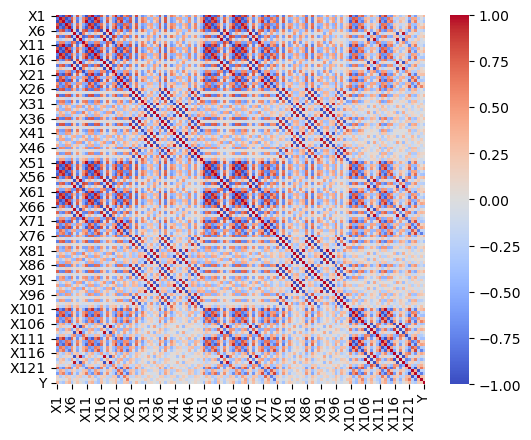

In [9]:
sns.heatmap(data.corr(), square=True, vmax=1, vmin=-1, center=0, cmap='coolwarm')

X = data.drop(columns=['Y'])
Y = data['Y']


print(f"Number of features: {X.shape[1]}")
print(f"Number of samples: {X.shape[0]}")
print(f"Number of classes: {Y.value_counts()}")
# =====================================================================
# ANOVA F-TEST (appropriate for continuous features vs categorical target)
# =====================================================================
anova_results = []

for col in X.columns:
    groups = [X[col][Y == cls] for cls in Y.unique()]
    f_stat, p_val = f_oneway(*groups)
    anova_results.append({'Feature': col, 'F-Statistic': f_stat, 'P-Value': p_val})

anova_df = pd.DataFrame(anova_results).sort_values('F-Statistic', ascending=False)
anova_df['Significant'] = anova_df['P-Value'] < 0.05

print("=== ANOVA Results ===")
print(anova_df.to_string(index=False))

# =====================================================================
# CHI-SQUARED TEST (only valid for non-negative integer/categorical features)
# Binning floats into quartiles to make it applicable
# =====================================================================
chi2_results = []

for col in X.columns:
    binned = pd.qcut(X[col], q=4, labels=False, duplicates='drop')
    contingency_table = pd.crosstab(binned, Y)
    chi2_stat, p_val, dof, expected = chi2_contingency(contingency_table)
    chi2_results.append({'Feature': col, 'Chi2-Statistic': chi2_stat, 'P-Value': p_val, 'DOF': dof})

chi2_df = pd.DataFrame(chi2_results).sort_values('Chi2-Statistic', ascending=False)
chi2_df['Significant'] = chi2_df['P-Value'] < 0.05

print("\n=== Chi-Squared Results (binned into quartiles) ===")
print(chi2_df.to_string(index=False))

# =====================================================================
# SUMMARY — features significant in both tests
# =====================================================================
both_significant = set(anova_df[anova_df['Significant']]['Feature']) & \
                   set(chi2_df[chi2_df['Significant']]['Feature'])

print(f"\nFeatures significant in both tests ({len(both_significant)}):")
print(both_significant)



<Axes: >

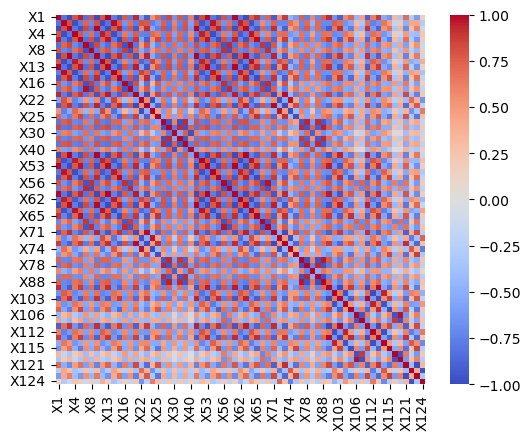

In [8]:
columns_drop = [col for col in data.columns if col not in both_significant]
sns.heatmap(data.drop(columns=columns_drop).corr(), square=True, vmax=1, vmin=-1, center=0, cmap='coolwarm')

In [12]:
x_train, x_test, y_train, y_test = train_test_split(X, Y, test_size=0.3, random_state=42)
scalar = StandardScaler()
x_train = scalar.fit_transform(x_train)
x_test = scalar.transform(x_test)

pca = PCA(n_components=0.95)  # Adjust the number of components as needed
x_train = pca.fit_transform(x_train)
x_test = pca.transform(x_test)

print(f'Number of components selected by PCA: {pca.n_components_}')

print(x_train.shape, x_test.shape)

Number of components selected by PCA: 9
(110, 9) (48, 9)
